# AUPRC Results of Fine Tuning

In [1]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path

#taekaway: complex models like haven need a lot more data to make the mot of their potential
#statistical tests to show statistical significance w number of stars for the models, comparing haven vs lr, haven vs rf, haven vs svm
#if space, do umap of embeddings. see if hosts cluster together. color by true hosts, see if emneddings form clusters
#auprc, auroc

['/home/sanjanag05/.conda/envs/haven/lib/python311.zip',
 '/home/sanjanag05/.conda/envs/haven/lib/python3.11',
 '/home/sanjanag05/.conda/envs/haven/lib/python3.11/lib-dynload',
 '',
 '/home/sanjanag05/.conda/envs/haven/lib/python3.11/site-packages',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../..']

In [2]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import mannwhitneyu, wilcoxon, ranksums, iqr

from src.utils import utils, evaluation_utils, visualization_utils

In [18]:
output_filepaths = {

# "4hosts_epoch100": os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/4hosts_epoch100_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv"),
# "3hosts_epoch100":  os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/3hosts_epoch100_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv"),
"3 hosts": os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/3hosts_epoch50_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv"),
"4 hosts": os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/4hosts_epoch50_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv"),
# # "lr" = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_lr_3hosts_lr_output.csv"),
# # "svm" = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_svm_3hosts_svm_output.csv"),
# # "rf" = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_rf_3hosts_rf_output.csv") 
"5 hosts": os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/mlm_1e-5_final.csv")
# "Random Forest": os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_rf_3hosts_rf_output.csv"),
# "SVM": os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_svm_3hosts_svm_output.csv"),
# "Logistic Regression": os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_lr_3hosts_lr_output.csv")
}

In [4]:
def classwise_auprc_analysis(output_filepaths, figure_output_filepath=None):
    itr_col = "itr"
    
    experiment_col = "experiment"
    y_true_col = "y_true"
    #utils.compute_class_distribution(df, y_true_col)
    auprc_results = []
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        print(len(df))  # should be 262
        print(df[y_true_col].value_counts())
        cols = df.columns
        classes = list(set(cols) - set([itr_col, experiment_col, y_true_col]))
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class":metadata_formatted}, inplace=True)
    sns.set_context("paper")
    sns.axes_style("whitegrid")
    
    FIGURE_CONFIG = {
        "figsize": (12, 6),
        "xtick.labelsize": 14,
        "ytick.labelsize": 14    
    }
    
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())
    
    visualization_utils.pre_plot_config(FIGURE_CONFIG)
    ax = sns.boxplot(data=auprc_results_df, x="class", y="auprc", hue="model", 
                     order=metadata_sorted, linewidth=1.5, fliersize=5, linecolor="black",
                     palette=color_palette)
    
    bg_colors = [ "gray", "white",]
    
    plt.draw()
    
    ax.set_ylim(0, 1)
    ax.set_ylabel("AUPRC", size=14)
    ax.set_xlabel("", size=0, labelpad=0)
    sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, 1), ncol=5, title=None, frameon=False)
    plt.setp(ax.get_legend().get_texts(), fontsize=14)
    visualization_utils.wrap_ticklabels(ax, axis="x")
    
    n_classes = auprc_results_df["class"].nunique()
    for i in range(n_classes):
        ax.axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    if figure_output_filepath:
        visualization_utils.view(figure_output_filepath)
    plt.show()

Read output original = (135, 8)
135
y_true
Human              65
Chicken            30
Cat                20
Pig                10
European rabbit     5
Gray wolf           5
Name: count, dtype: int64
Read output 3hosts_epoch50 = (116, 5)
116
y_true
Human      60
Chicken    30
Cat        26
Name: count, dtype: int64
Read output 4hosts_epoch50 = (120, 6)
120
y_true
Human      60
Chicken    30
Cat        20
Pig        10
Name: count, dtype: int64


/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


<Figure size 640x480 with 0 Axes>

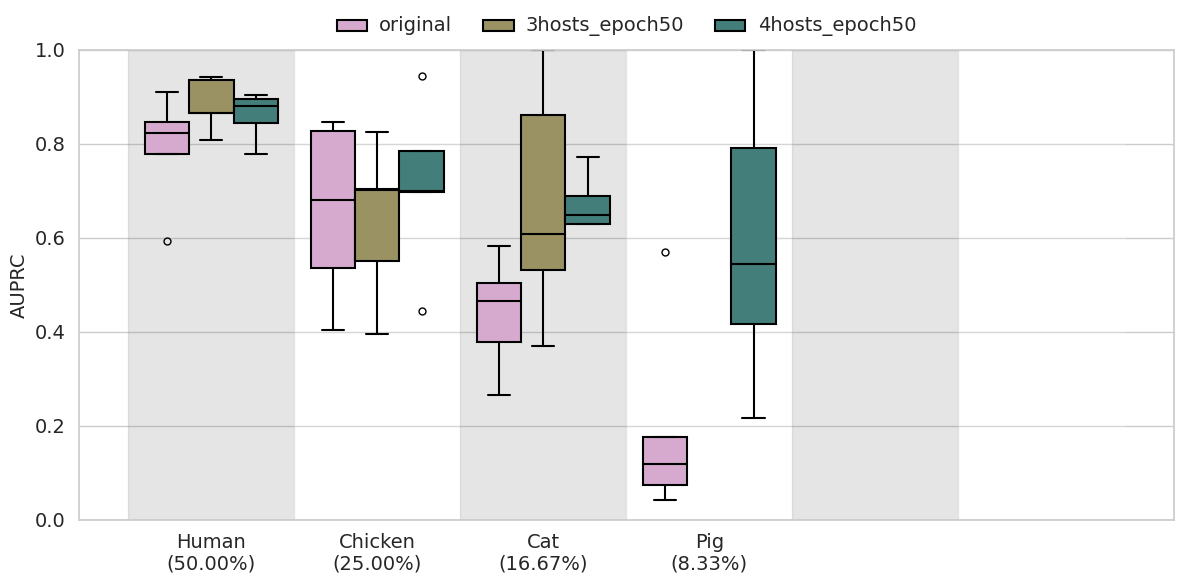

In [5]:

figure_output_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/visualization/uniref50/host_multi_all_models_classwise_aurpc_boxplot.pdf")
classwise_auprc_analysis(output_filepaths, figure_output_filepath)

In [6]:
file = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/mlm_1e-5_final.csv")
df = pd.read_csv(file, index_col=0)
df[df["itr"] == 0]["y_true"].value_counts()

#just human chicken and cat, just pick the best (epoch50 or epoch100)
#human chicken cat pig, remove gray wolfand rabbit
#record how many epochs are taken
#just for haven

y_true
Human              13
Chicken             6
Cat                 4
Pig                 2
European rabbit     1
Gray wolf           1
Name: count, dtype: int64

# Analysis

For human, pig, and gray wolf, <b> epoch50 </b> is better

For european rabbit, <b> both </b> are tied

For cat, <b> epoch100 </b> seems to be better

For chicken, <b> epoch50 has better median </b>, but <b> epoch100 </b> has better peak performance

I think that Epoch50 is the best one because it is better on average. Even though epoch100 usually has better peak performance, epoch50 will be better consistently

# All Model Analysis

In [7]:
def macro_and_classwise_auprc_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    classes = None
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        print(len(df))
        print(df[y_true_col].value_counts())
        
        cols = df.columns
        classes = list(set(cols) - set([itr_col, experiment_col, y_true_col]))
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(1, 2, figsize=(18, 6), sharex=False, sharey=True, gridspec_kw={"width_ratios": [1, 3]})
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0],
                linewidth=1.5, fliersize=5, linecolor="black", legend=False)
    
    sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, fliersize=5, linecolor="black", order=metadata_sorted, palette=color_palette, ax=axs[1])
    #sns.violinplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", orient="v", order=metadata_sorted, palette=color_palette, ax=axs[1], legend="auto")
    # plt.draw()
    axs[0].set_ylim(0.0, 1)
    axs[1].set_ylim(0.0, 1)
    axs[0].set_ylabel("AUPRC", size=20)
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[1].set_xlabel("", size=0, labelpad=0)
    sns.move_legend(axs[1], "lower center", bbox_to_anchor=(.35, 1), ncol=5, title=None, frameon=False)
    plt.setp(axs[1].get_legend().get_texts(), fontsize=20)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(axs[1], axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    plt.subplots_adjust(wspace=0.01)
    plt.tight_layout()
    plt.savefig(figure_output_filepath, dpi=600)
    plt.subplots_adjust(wspace=-1.5)
    plt.show()
    return auprc_results_df

Read output original = (135, 8)
135
y_true
Human              65
Chicken            30
Cat                20
Pig                10
European rabbit     5
Gray wolf           5
Name: count, dtype: int64
Read output 3hosts_epoch50 = (116, 5)
116
y_true
Human      60
Chicken    30
Cat        26
Name: count, dtype: int64
Read output 4hosts_epoch50 = (120, 6)
120
y_true
Human      60
Chicken    30
Cat        20
Pig        10
Name: count, dtype: int64


/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


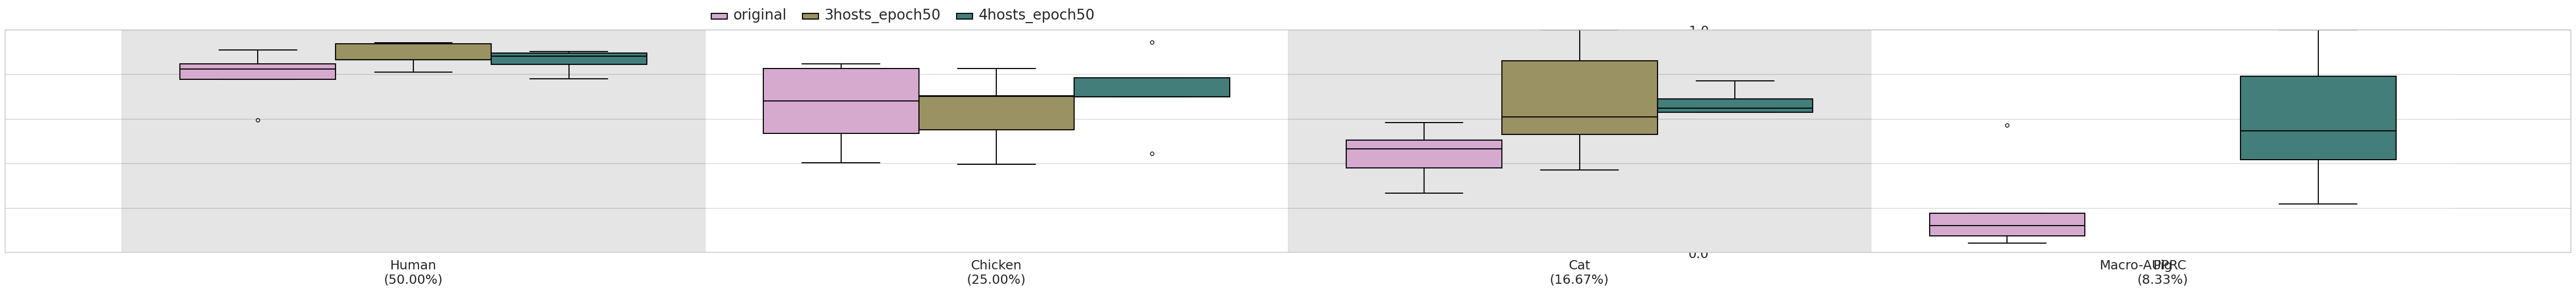

In [8]:
classes = ["Human", "Chicken", "Cat"]
auprc_results_df = macro_and_classwise_auprc_analysis(output_filepaths, classes, 
                          figure_output_filepath=os.path.join(os.getcwd(), "..", "..", "..", "..", f"output/visualization/uniref50/host_multi_uniref50_combined_auprc.pdf"))

In [9]:
auprc_results_df[["model", "class", "auprc"]].groupby(["model", "class"]).agg(["mean", "std", "median", iqr])
auprc_results_df[auprc_results_df["class"] == "Human (47.17%)"]["auprc"].median()

nan

In [21]:
pairs = [("3 hosts", "4 hosts"),
         ("3 hosts", "5 hosts")]
# pairs = [("3hosts_epoch50", "3hosts_epoch100"),
# "original": os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/mlm_1e-5_final.csv"),
# "4hosts_epoch100": os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/4hosts_epoch100_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv"),
# "3hosts_epoch100":  os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/3hosts_epoch100_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv"),
# "3hosts_epoch50": os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/3hosts_epoch50_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv"),
# "4hosts_epoch50": 
#         ("4hosts_epoch50", "4hosts_epoch100")]


def get_p_value_annotation(p_value):
    if p_value > 5e-2 and p_value <= 1:
        return "ns"
    elif p_value > 1e-2 and p_value <= 5e-2:
        return "*"
    elif p_value > 1e-3 and p_value <= 1e-2:
        return "**"
    elif p_value > 1e-4 and p_value <= 1e-3:
        return "***"
    elif p_value <= 1e-4:
        return "****"
    else:
        return None

def combined_auprc_analysis_w_stat(output_filepaths, figure_output_filepath=None):
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    auprc_results = []
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        
        cols = df.columns
        classes = list(set(cols) - set([itr_col, experiment_col, y_true_col]))
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
        
    #metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    print(models)
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class":metadata_formatted}, inplace=True)
    sns.set_context("paper")
    sns.axes_style("whitegrid")

    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 15})
    fig, axs = plt.subplots(2, 1, figsize=(16, 12))
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1.2, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())
    #color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=df["experiment"].nunique())
    #visualization_utils.pre_plot_config(FIGURE_CONFIG)
    
    ############# First plot ###############
    sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="model", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0], order=models, legend=False,
                linewidth=1.5, fliersize=5, linecolor="black")
    sns.stripplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="model", y="auprc", ax=axs[0], color="black", size=8, alpha=.7,
                  order=models)


    for i, pair in enumerate(pairs):
        model_1_values = auprc_results_df[(auprc_results_df["class"] == "Macro-AUPRC") & (auprc_results_df["model"] == pair[0])]["auprc"].values
        model_2_values = auprc_results_df[(auprc_results_df["class"] == "Macro-AUPRC") & (auprc_results_df["model"] == pair[1])]["auprc"].values
        p_value = mannwhitneyu(model_1_values, model_2_values, alternative="two-sided").pvalue
        formatted_pvalue = f"p={p_value:.2e}"
        print(f"{pair}: p-value={formatted_pvalue}")
        
        x1 = models.index(pair[0])
        x2 = models.index(pair[1])
        y1 = max(model_1_values.max(), model_2_values.max()) + (0.06 * (i + 1))
        y2 = y1 + .01
        
        axs[0].plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=2, c="k")
        text = get_p_value_annotation(p_value)
        if text == "ns":
            axs[0].text((x1 + x2)*.5, y1+0.01, text , ha='center', va='bottom', color="k", size="18")
        else:
            axs[0].text((x1 + x2)*.5, y1, text, ha='center', va='bottom', color="k", size="18")

    
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[0].set_ylabel("Macro-AUPRC", size=20)
    axs[0].set_ylim(0, 1.1)

    ############# Second plot ###############
    sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", 
                     order=metadata_formatted.values(), linewidth=1.5, fliersize=5, linecolor="black",
                     palette=color_palette, ax=axs[1])
    
    bg_colors = [ "gray", "white",]
        
    # axs[1].set_ylim(0, 1)
    # axs[1].set_ylabel("AUPRC", size=20)
    # axs[1].set_xlabel("", size=0, labelpad=0)
    sns.move_legend(axs[1], "lower center", bbox_to_anchor=(.5, 1), ncol=5, title=None, frameon=False)
    plt.setp(axs[1].get_legend().get_texts(), fontsize=18)
    visualization_utils.wrap_ticklabels(axs[1], axis="x")
    
    n_classes = auprc_results_df["class"].nunique() - 1 # -1 to account for Macro-AUPRC
    for i in range(n_classes):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)

    axs[0].text(x=-1.5, y=1.1, s="A", fontsize=24, color="black")
   # axs[1].text(x=-1.1, y=1.1, s="B", fontsize=24, color="black")
    axs[0].margins(0.01, tight=True)
    #axs[1].margins(0.01, tight=True)
    if figure_output_filepath:
        plt.savefig(figure_output_filepath, bbox_inches="tight")
    plt.show()

Read output 3 hosts = (116, 5)
Read output 4 hosts = (120, 6)
Read output 5 hosts = (135, 8)
['3 hosts', '4 hosts', '5 hosts']
('3 hosts', '4 hosts'): p-value=p=6.90e-01
('3 hosts', '5 hosts'): p-value=p=1.59e-02


/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


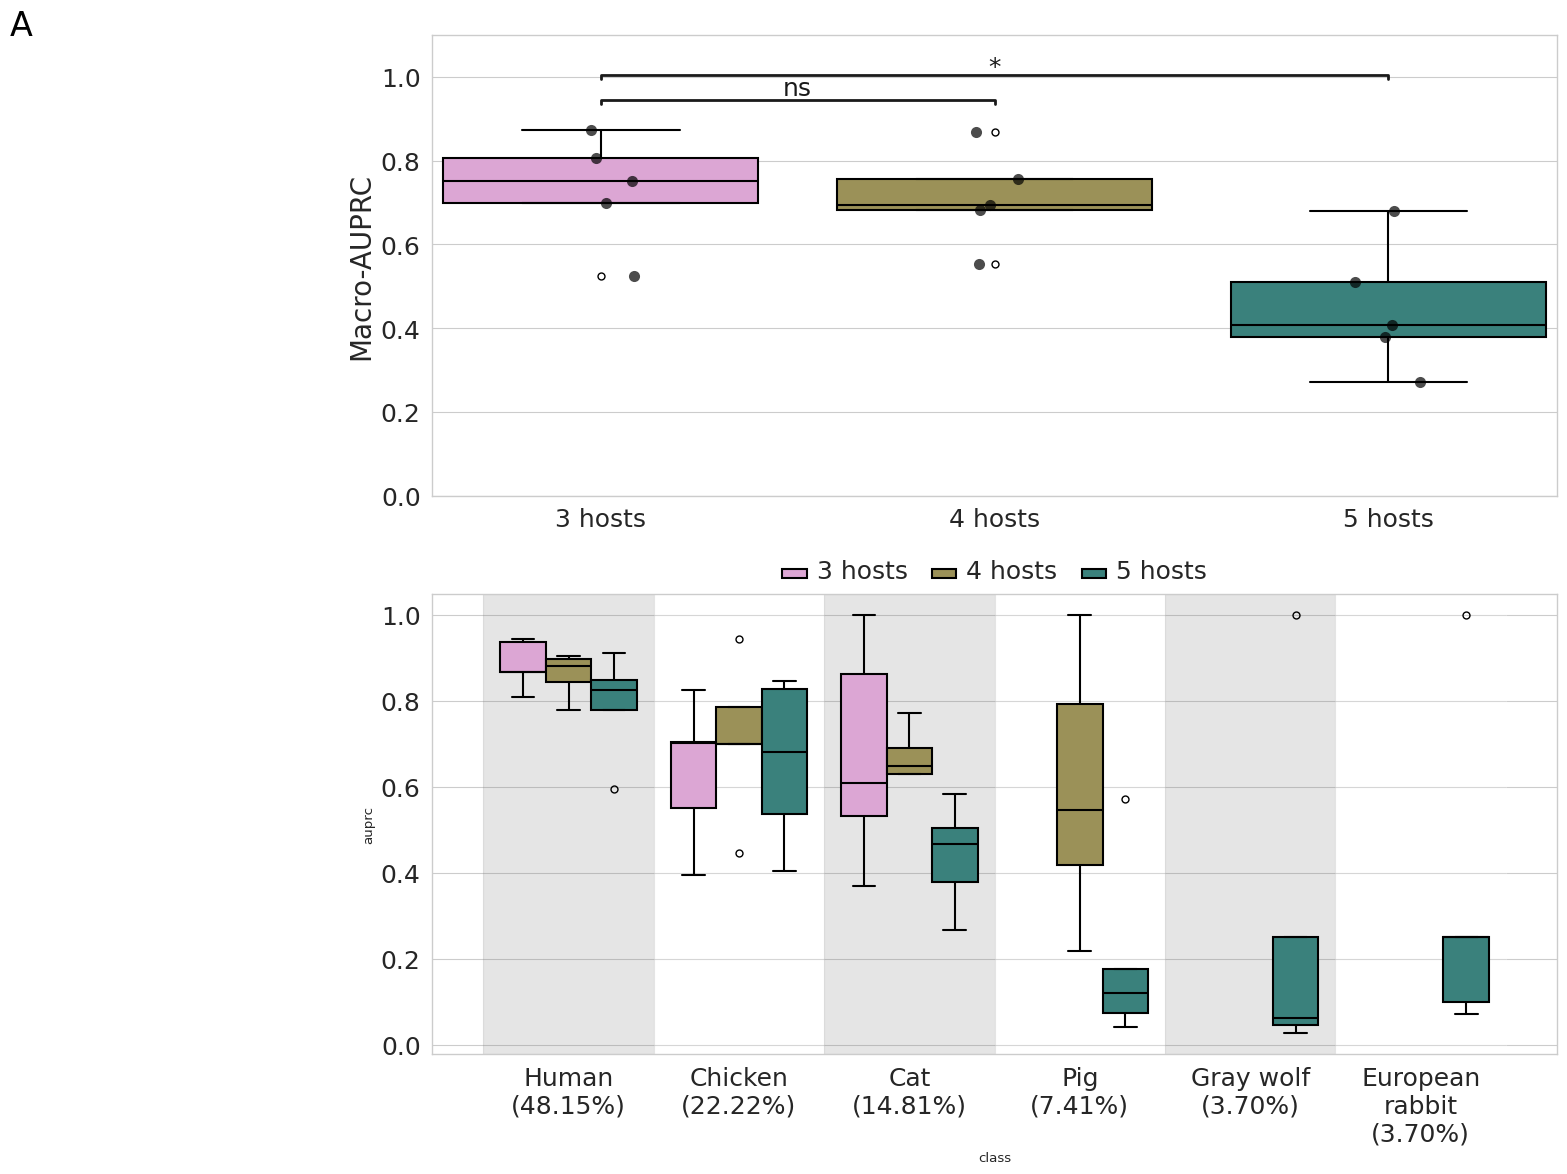

In [22]:
figure_output_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "output/visualization/uniref50/haven_models.pdf")
combined_auprc_analysis_w_stat(output_filepaths, figure_output_filepath=figure_output_filepath)

# Analysis

Random Forest has the best AUPRC scores and distributions for our data